## Load and Preprocess Data



In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/mobile_game_inapp_purchases.csv')

# Display the first few rows and check data types
print("First 5 rows of the dataset:")
print(df.head())

print("\nData types and non-null values:")
df.info()

First 5 rows of the dataset:
                                 UserID   Age  Gender      Country   Device  \
0  c9889ab0-9cfc-4a75-acd9-5eab1df0015c  49.0    Male       Norway  Android   
1  7c9e413c-ecca-45f2-a780-2826a07952a2  15.0    Male  Switzerland      iOS   
2  fd61e419-1a92-4f43-a8c7-135842ad328a  23.0    Male        China  Android   
3  bdb7f6d1-ff9a-468c-afe7-43f32a94293e  31.0    Male       Mexico  Android   
4  aa7eec14-4846-47b9-b879-9c98038cda04  37.0  Female        India  Android   

       GameGenre  SessionCount  AverageSessionLength SpendingSegment  \
0  Battle Royale             9                 12.83          Minnow   
1     Action RPG            11                 19.39          Minnow   
2       Fighting             9                  8.87          Minnow   
3         Racing            12                 19.56          Minnow   
4  Battle Royale            10                 15.23          Minnow   

   InAppPurchaseAmount  FirstPurchaseDaysAfterInstall PaymentMe

In [ ]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nPercentage of missing values per column:")
print((df.isnull().sum() / len(df)) * 100)


Missing values per column:
UserID                             0
Age                               60
Gender                            60
Country                           60
Device                            60
GameGenre                         60
SessionCount                       0
AverageSessionLength               0
SpendingSegment                    0
InAppPurchaseAmount              136
FirstPurchaseDaysAfterInstall    136
PaymentMethod                    136
LastPurchaseDate                 136
dtype: int64

Percentage of missing values per column:
UserID                           0.000000
Age                              1.984127
Gender                           1.984127
Country                          1.984127
Device                           1.984127
GameGenre                        1.984127
SessionCount                     0.000000
AverageSessionLength             0.000000
SpendingSegment                  0.000000
InAppPurchaseAmount              4.497354
FirstPurchaseDay

In [ ]:
df_cleaned = df.dropna()
print(f"Original number of rows: {len(df)}")
print(f"Number of rows after dropping missing values: {len(df_cleaned)}")
print("\nMissing values after dropping rows:")
print(df_cleaned.isnull().sum())

Original number of rows: 3024
Number of rows after dropping missing values: 2612

Missing values after dropping rows:
UserID                           0
Age                              0
Gender                           0
Country                          0
Device                           0
GameGenre                        0
SessionCount                     0
AverageSessionLength             0
SpendingSegment                  0
InAppPurchaseAmount              0
FirstPurchaseDaysAfterInstall    0
PaymentMethod                    0
LastPurchaseDate                 0
dtype: int64


In [ ]:
df_processed = df_cleaned.drop(columns=['UserID', 'LastPurchaseDate'])

categorical_cols_to_encode = df_processed.select_dtypes(include='object').columns
numerical_cols_to_scale = df_processed.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns to be encoded:", list(categorical_cols_to_encode))
print("Numerical columns to be scaled:", list(numerical_cols_to_scale))

Categorical columns to be encoded: ['Gender', 'Country', 'Device', 'GameGenre', 'SpendingSegment', 'PaymentMethod']
Numerical columns to be scaled: ['Age', 'SessionCount', 'AverageSessionLength', 'InAppPurchaseAmount', 'FirstPurchaseDaysAfterInstall']


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Separate features and potential target variable (SpendingSegment as an example)
X = df_processed.drop(columns=['SpendingSegment'])
y = df_processed['SpendingSegment']

# Identify categorical and numerical columns in X
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for one-hot encoding categorical features and scaling numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Apply the preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# The numerical features will retain their original names
numeric_feature_names = list(numerical_features)

# Get categorical feature names after one-hot encoding
# This needs to be done carefully as OneHotEncoder dynamically creates new columns
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Combine all feature names
all_feature_names = numeric_feature_names + list(encoded_cat_feature_names)

# Convert the processed array back to a DataFrame for easier handling and inspection
df_final_features = pd.DataFrame(X_processed, columns=all_feature_names)

print("Shape of the final processed features DataFrame:", df_final_features.shape)
print("First 5 rows of the final processed features DataFrame:")
print(df_final_features.head())
print("\nTarget variable unique values:", y.unique())

Shape of the final processed features DataFrame: (2612, 59)
First 5 rows of the final processed features DataFrame:
        Age  SessionCount  AverageSessionLength  InAppPurchaseAmount  \
0  1.298912     -0.334444             -0.846469            -0.200323   
1 -1.534984      0.306471             -0.079757            -0.211150   
2 -0.868185     -0.334444             -1.309302            -0.190831   
3 -0.201386      0.626929             -0.059888            -0.195825   
4  0.298713     -0.013986             -0.565965            -0.201486   

   FirstPurchaseDaysAfterInstall  Gender_Female  Gender_Male  Gender_Other  \
0                       1.408997            0.0          1.0           0.0   
1                       0.289446            0.0          1.0           0.0   
2                       1.632908            0.0          1.0           0.0   
3                      -0.718150            0.0          1.0           0.0   
4                      -0.046419            1.0          0.0 

## Basic SVM with Linear Kernel



Shape of X_train: (2089, 59)
Shape of X_test: (523, 59)
Shape of y_train: (2089,)
Shape of y_test: (523,)

Model Accuracy: 0.9713


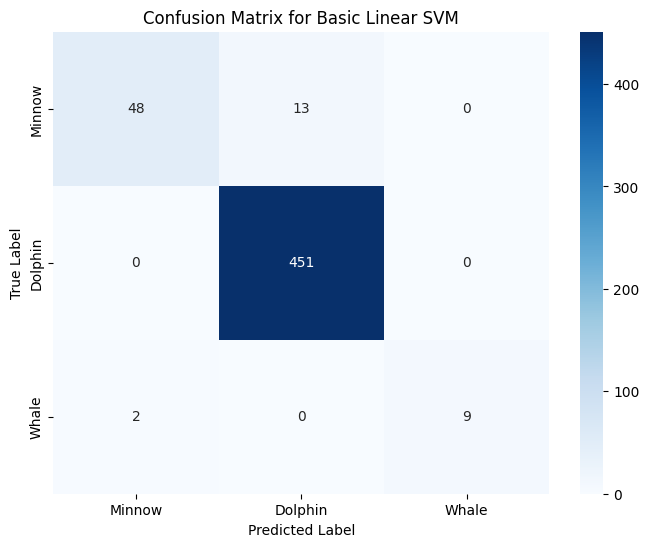

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_final_features, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# 2. Instantiate and train an SVM classifier with a linear kernel
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = svm_linear.predict(X_test)

# 4. Evaluate the model's accuracy and generate a confusion matrix
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=y.unique(), yticklabels=y.unique())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Basic Linear SVM')
plt.show()

## Advanced SVM with Multiple Kernels and Hyperparameter Tuning




In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define parameter grids for each kernel type
param_grid_linear = {
    'C': [0.1, 1, 10, 100]
}

param_grid_poly = {
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto']
}

param_grid_rbf = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

# Initialize SVM classifiers
svm_linear_base = SVC(kernel='linear', random_state=42)
svm_poly_base = SVC(kernel='poly', random_state=42)
svm_rbf_base = SVC(kernel='rbf', random_state=42)

# Perform GridSearchCV for each kernel
print("\n--- Tuning Linear SVM ---")
grid_search_linear = GridSearchCV(svm_linear_base, param_grid_linear, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_linear.fit(X_train, y_train)
print(f"Best parameters for Linear SVM: {grid_search_linear.best_params_}")
print(f"Best cross-validation accuracy for Linear SVM: {grid_search_linear.best_score_:.4f}")

print("\n--- Tuning Polynomial SVM ---")
grid_search_poly = GridSearchCV(svm_poly_base, param_grid_poly, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_poly.fit(X_train, y_train)
print(f"Best parameters for Polynomial SVM: {grid_search_poly.best_params_}")
print(f"Best cross-validation accuracy for Polynomial SVM: {grid_search_poly.best_score_:.4f}")

print("\n--- Tuning RBF SVM ---")
grid_search_rbf = GridSearchCV(svm_rbf_base, param_grid_rbf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rbf.fit(X_train, y_train)
print(f"Best parameters for RBF SVM: {grid_search_rbf.best_params_}")
print(f"Best cross-validation accuracy for RBF SVM: {grid_search_rbf.best_score_:.4f}")

# Get the best estimators
best_svm_linear = grid_search_linear.best_estimator_
best_svm_poly = grid_search_poly.best_estimator_
best_svm_rbf = grid_search_rbf.best_estimator_

# Evaluate the best estimators on the test set
accuracy_linear = best_svm_linear.score(X_test, y_test)
accuracy_poly = best_svm_poly.score(X_test, y_test)
accuracy_rbf = best_svm_rbf.score(X_test, y_test)

print("\n--- Test Set Accuracy of Best Models ---")
print(f"Linear SVM Test Accuracy: {accuracy_linear:.4f}")
print(f"Polynomial SVM Test Accuracy: {accuracy_poly:.4f}")
print(f"RBF SVM Test Accuracy: {accuracy_rbf:.4f}")

# Compare and discuss results
print("\n--- Comparison of SVM Models ---")
accuracies = {
    'Linear SVM': accuracy_linear,
    'Polynomial SVM': accuracy_poly,
    'RBF SVM': accuracy_rbf
}

best_model_name = max(accuracies, key=accuracies.get)
best_model_accuracy = accuracies[best_model_name]

print(f"The best performing kernel on the test set is {best_model_name} with an accuracy of {best_model_accuracy:.4f}.")


--- Tuning Linear SVM ---
Best parameters for Linear SVM: {'C': 100}
Best cross-validation accuracy for Linear SVM: 0.9914

--- Tuning Polynomial SVM ---
Best parameters for Polynomial SVM: {'C': 10, 'degree': 2, 'gamma': 'scale'}
Best cross-validation accuracy for Polynomial SVM: 0.9545

--- Tuning RBF SVM ---
Best parameters for RBF SVM: {'C': 100, 'gamma': 'auto'}
Best cross-validation accuracy for RBF SVM: 0.9809

--- Test Set Accuracy of Best Models ---
Linear SVM Test Accuracy: 0.9924
Polynomial SVM Test Accuracy: 0.9560
RBF SVM Test Accuracy: 0.9809

--- Comparison of SVM Models ---
The best performing kernel on the test set is Linear SVM with an accuracy of 0.9924.


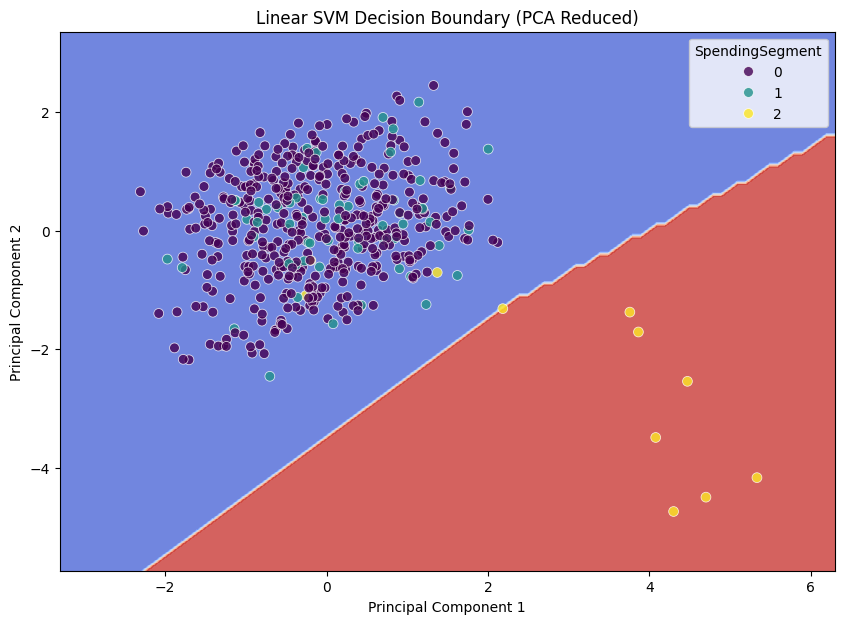

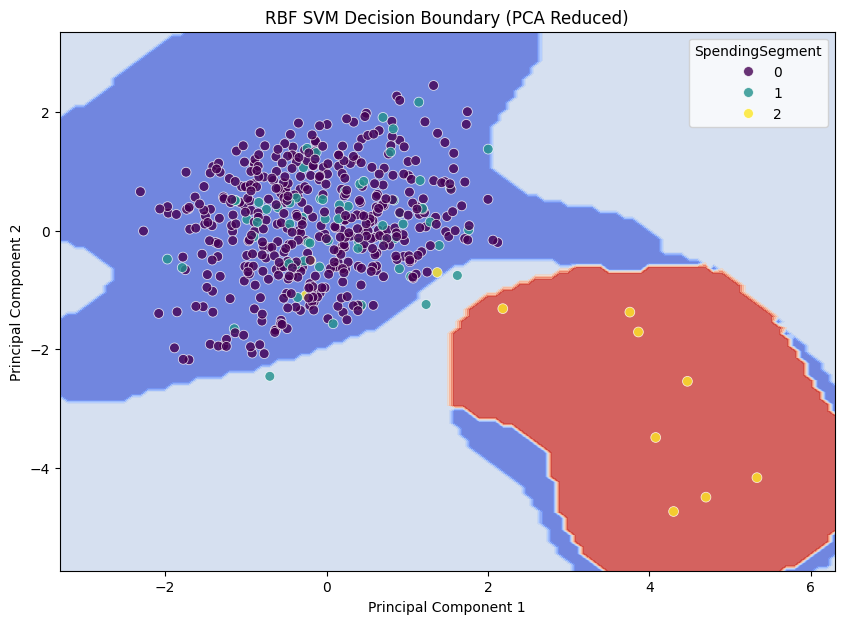

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


# For visualization purposes, let's map 'Minnow', 'Dolphin', 'Whale' to 0, 1, 2
label_mapping = {'Minnow': 0, 'Dolphin': 1, 'Whale': 2}
y_train_num = y_train.map(label_mapping)
y_test_num = y_test.map(label_mapping)

# Function to plot decision boundaries
def plot_decision_boundary(X_pca, y_num, model, title):
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))



    # A separate model specifically for visualization purposes, not the one evaluated previously
    svm_vis = SVC(kernel=model.kernel, C=model.C, random_state=42)
    if model.kernel == 'poly':
        svm_vis = SVC(kernel=model.kernel, C=model.C, degree=model.degree, gamma=model.gamma, random_state=42)
    elif model.kernel == 'rbf':
        svm_vis = SVC(kernel=model.kernel, C=model.C, gamma=model.gamma, random_state=42)

    svm_vis.fit(X_pca, y_num)
    Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_num, palette='viridis', legend='full', s=50, alpha=0.8)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(title)
    plt.show()

# Plot decision boundaries for the best linear and RBF SVM models (using PCA-reduced data)

plot_decision_boundary(X_test_pca, y_test_num, best_svm_linear, 'Linear SVM Decision Boundary (PCA Reduced)')
plot_decision_boundary(X_test_pca, y_test_num, best_svm_rbf, 'RBF SVM Decision Boundary (PCA Reduced)')

## Scenario-Based Task (Binary Classification)




Original 'SpendingSegment' unique values: ['Minnow' 'Dolphin' 'Whale']
New binary target 'y_binary' value counts:
SpendingSegment
0    2555
1      57
Name: count, dtype: int64

Shape of X_train_binary: (2089, 59)
Shape of X_test_binary: (523, 59)
Shape of y_train_binary: (2089,)
Shape of y_test_binary: (523,)

Binary Classification Accuracy: 0.9962
Precision (Whale class): 1.0000
Recall (Whale class): 0.8182
F1-Score (Whale class): 0.9000


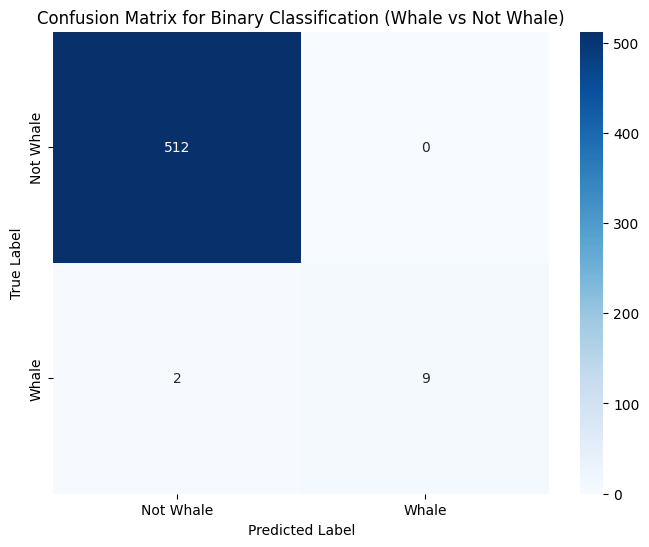

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a new binary target variable
y_binary = df_processed['SpendingSegment'].apply(lambda x: 1 if x == 'Whale' else 0)

print("Original 'SpendingSegment' unique values:", df_processed['SpendingSegment'].unique())
print("New binary target 'y_binary' value counts:")
print(y_binary.value_counts())

# 2. Split the features and the new binary target variable into training and testing sets
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    df_final_features, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\nShape of X_train_binary: {X_train_binary.shape}")
print(f"Shape of X_test_binary: {X_test_binary.shape}")
print(f"Shape of y_train_binary: {y_train_binary.shape}")
print(f"Shape of y_test_binary: {y_test_binary.shape}")

# 3. Instantiate an SVM classifier with an RBF kernel
svm_rbf_binary = SVC(kernel='rbf', random_state=42)

# 4. Train the RBF SVM model on the training data
svm_rbf_binary.fit(X_train_binary, y_train_binary)

# 5. Make predictions on the test set
y_pred_binary = svm_rbf_binary.predict(X_test_binary)

# 6. Calculate and print the accuracy score
accuracy_binary = accuracy_score(y_test_binary, y_pred_binary)
print(f"\nBinary Classification Accuracy: {accuracy_binary:.4f}")

# 7. Calculate and print precision, recall, and F1-score
# 'pos_label=1' indicates that we are interested in the metrics for the 'Whale' class
precision_binary = precision_score(y_test_binary, y_pred_binary, pos_label=1)
recall_binary = recall_score(y_test_binary, y_pred_binary, pos_label=1)
f1_binary = f1_score(y_test_binary, y_pred_binary, pos_label=1)

print(f"Precision (Whale class): {precision_binary:.4f}")
print(f"Recall (Whale class): {recall_binary:.4f}")
print(f"F1-Score (Whale class): {f1_binary:.4f}")

# Get the confusion matrix
conf_matrix_binary = confusion_matrix(y_test_binary, y_pred_binary)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Whale', 'Whale'], yticklabels=['Not Whale', 'Whale'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Binary Classification (Whale vs Not Whale)')
plt.show()

## Challenging Multi-Class Classification using OvR and OvO strategies



In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Instantiate a base SVM classifier (SVC defaults to One-vs-One for multi-class)
svm_ovo = SVC(kernel='rbf', random_state=42)

# Instantiate a One-vs-Rest classifier using an SVM base estimator
svm_ovr = OneVsRestClassifier(SVC(kernel='rbf', random_state=42))

print("\n--- Training One-vs-One SVM ---")
# Train the One-vs-One SVM model
svm_ovo.fit(X_train, y_train)
y_pred_ovo = svm_ovo.predict(X_test)
print("One-vs-One Classification Report:")
print(classification_report(y_test, y_pred_ovo))

print("\n--- Training One-vs-Rest SVM ---")
# Train the One-vs-Rest SVM model
svm_ovr.fit(X_train, y_train)
y_pred_ovr = svm_ovr.predict(X_test)
print("One-vs-Rest Classification Report:")
print(classification_report(y_test, y_pred_ovr))



--- Training One-vs-One SVM ---
One-vs-One Classification Report:
              precision    recall  f1-score   support

     Dolphin       0.95      0.59      0.73        61
      Minnow       0.95      1.00      0.97       451
       Whale       1.00      0.82      0.90        11

    accuracy                           0.95       523
   macro avg       0.96      0.80      0.87       523
weighted avg       0.95      0.95      0.94       523


--- Training One-vs-Rest SVM ---
One-vs-Rest Classification Report:
              precision    recall  f1-score   support

     Dolphin       0.94      0.56      0.70        61
      Minnow       0.94      1.00      0.97       451
       Whale       1.00      0.82      0.90        11

    accuracy                           0.94       523
   macro avg       0.96      0.79      0.86       523
weighted avg       0.94      0.94      0.94       523



# # Mobile Game In-App Purchases Prediction using Support Vector Machines (SVM)

This repository contains an end-to-end Machine Learning pipeline utilizing **Support Vector Machines (SVM)** to analyze and predict user spending segments in a mobile gaming application. The project addresses data preprocessing, hyperparameter optimization across multiple SVM kernels, decision boundary visualization, and handling of class imbalances via multi-class classification strategies.

---

##  Table of Contents
1. [Project Overview](#-project-overview)
2. [Dataset Description](#-dataset-description)
3. [Key Methodology](#-key-methodology)
4. [Model Performance Summary](#-model-performance-summary)
5. [Visualizations](#-visualizations)
6. [How to Run the Project](#-how-to-run-the-project)

---

##  Project Overview
Mobile game developers rely on understanding user monetization patterns to customize in-game experiences and optimize player lifetime value. This project uses player demographics, session behavior, and payment information to predict a player's spending profile (**Minnow, Dolphin, Whale**).

We design, tune, and evaluate several Support Vector Machine (SVM) strategies to classify players effectively, including:
* **Binary Classification**: Identifying high-value targets (Whales vs. Others).
* **Multi-Class Classification**: Comparing standard One-vs-One (OvO) and One-vs-Rest (OvR) decision boundaries.

---

##  Dataset Description
The dataset (`mobile_game_inapp_purchases.csv`) tracks in-game actions and spending profiles of 3,024 players:

* **Demographics**: `Age`, `Gender`, `Country`.
* **Device & Platform**: `Device` (Android/iOS).
* **Player Engagement**: `SessionCount`, `AverageSessionLength`, `GameGenre`.
* **Monetization & Purchases**: `InAppPurchaseAmount`, `FirstPurchaseDaysAfterInstall`, `PaymentMethod`, `LastPurchaseDate`.
* **Target Feature (`SpendingSegment`)**:
  * `Minnow`: Low spenders.
  * `Dolphin`: Medium spenders.
  * `Whale`: High-value/High spenders.

---

##  Key Methodology

### 1. Data Cleaning & Preprocessing
* **Missing Values**: Handled using row-wise drop strategy (clean sample size reduced to 2,612 rows).
* **Feature Engineering**: Dropped high-cardinality/unnecessary identification features (`UserID`, `LastPurchaseDate`).
* **Pipeline Scaling & Encoding**: Used `ColumnTransformer` to:
  * Standard scale all continuous numerical features (`StandardScaler`).
  * One-hot encode categorical features (`OneHotEncoder`).

### 2. Hyperparameter Tuning (`GridSearchCV`)
We performed cross-validation to search for optimal SVM parameters:
* **Linear Kernel**: Tuned regularization strength $C$.
* **Polynomial Kernel**: Tuned $C$, $degree$, and $gamma$.
* **RBF Kernel**: Tuned $C$ and $gamma$.

### 3. Advanced Multi-class Strategies
Compared standard multi-class models utilizing **One-vs-One (OvO)** and **One-vs-Rest (OvR)** wrappers to handle inherent class imbalance (Whales constitute ~2.2% of the active user base).

---

##  Model Performance Summary

### **Kernel Tuning Results**
| SVM Kernel | Best Parameters | CV Accuracy | Test Accuracy |
| :--- | :--- | :---: | :---: |
| **Linear SVM** | `{'C': 100}` | **99.14%** | **99.24%** |
| **RBF SVM** | `{'C': 100, 'gamma': 'auto'}` | 98.09% | 98.09% |
| **Polynomial SVM** | `{'C': 10, 'degree': 2, 'gamma': 'scale'}` | 95.45% | 95.60% |

### **Strategy Evaluation (RBF Multi-class)**
* **One-vs-One (OvO) Accuracy**: **95%**
* **One-vs-Rest (OvR) Accuracy**: **94%**
* Both models achieved an **F1-Score of 90.00%** on the highly imbalanced 'Whale' target segment, showing strong robustness to class skewness.

---

##  Visualizations
The repository code includes steps to generate key insight visualizers:
1. **Confusion Matrix**: Visualizing error distribution across Minnow, Dolphin, and Whale classes.
2. **PCA Decision Boundaries**: Projects 59-dimensional processed features into 2D space via Principal Component Analysis (PCA) to illustrate the decision boundaries of Linear vs. RBF kernel models.

---

##  How to Run the Project

### Prerequisites
Make sure you have Python 3.8+ installed along with the required libraries:
```bash
pip install pandas numpy scikit-learn matplotlib seaborn
```

### Execution
1. Place your `mobile_game_inapp_purchases.csv` dataset in the project directory.
2. Run the main Jupyter / Google Colab Notebook sequentially to preprocess, train, tune, and evaluate the models.